# 06. Model Evaluation & Error Analysis

**Tác giả / Nhóm thực hiện:** Real Estate Data Science Team  
**Mô hình chính:** Multiple Linear Regression (`sklearn.linear_model.LinearRegression`)  
**Mục đích:** Đánh giá hiệu năng mô hình trên tập Test cho cả hai khu vực (Hà Nội và TP.HCM), trực quan hóa tương quan dự đoán, phân tích sai số (Residual Diagnostics) và phân tích các trường hợp sai lệch lớn nhất.


In [1]:
import sys
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sys.path.append('../src')
from visualization import (
    plot_actual_vs_predicted,
    plot_residual_distribution,
    plot_residual_vs_predicted,
    plot_absolute_error_distribution,
    plot_error_by_price_range,
    plot_top_prediction_errors
)

# Load base data
df_feat = pd.read_csv('../data/processed/housing_features.csv')


## PHẦN 1: ĐÁNH GIÁ MÔ HÌNH TP.HCM (HỒ CHÍ MINH)

In [2]:
df_hcm = df_feat[df_feat['province'] == 'Hồ Chí Minh'].copy()
X_hcm = df_hcm.drop(columns=['price_million_vnd'])
y_hcm = df_hcm['price_million_vnd']
X_train_hcm, X_test_hcm, y_train_hcm, y_test_hcm = train_test_split(X_hcm, y_hcm, test_size=0.2, random_state=42)

model_hcm = joblib.load('../models/linear_regression_hcm.pkl')
y_pred_hcm = model_hcm.predict(X_test_hcm)

print(f"--- TP.HCM METRICS ---")
print(f"Test Set Size: {len(y_test_hcm):,} samples")
print(f"R² Score:      {r2_score(y_test_hcm, y_pred_hcm):.4f}")
print(f"MAE:           {mean_absolute_error(y_test_hcm, y_pred_hcm):,.2f} million VND")
print(f"RMSE:          {np.sqrt(mean_squared_error(y_test_hcm, y_pred_hcm)):,.2f} million VND")


--- TP.HCM METRICS ---
Test Set Size: 4,215 samples
R² Score:      0.3171
MAE:           6,640.81 million VND
RMSE:          19,131.09 million VND


(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Top 20 Largest Prediction Errors (Absolute Error in Million VND)'}, xlabel='Absolute Prediction Error |Actual - Predicted| (Million VND)'>)

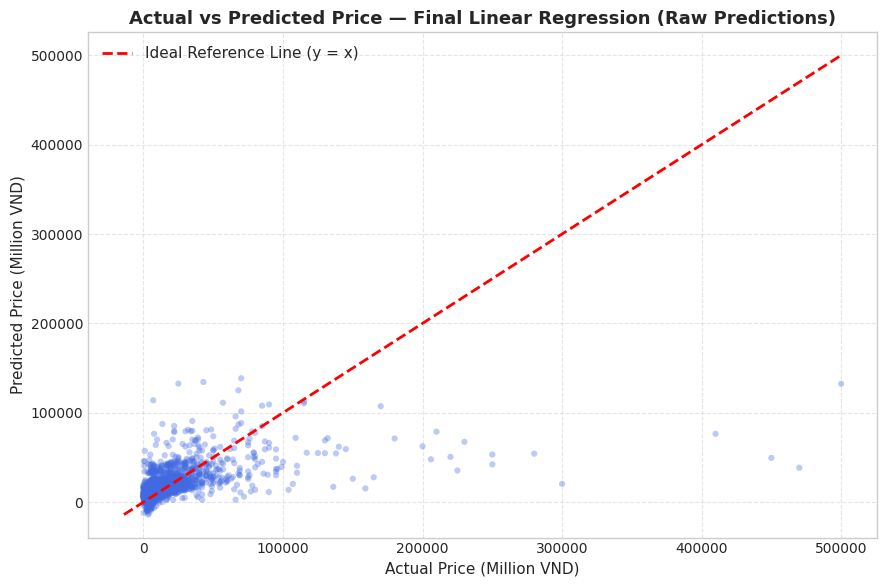

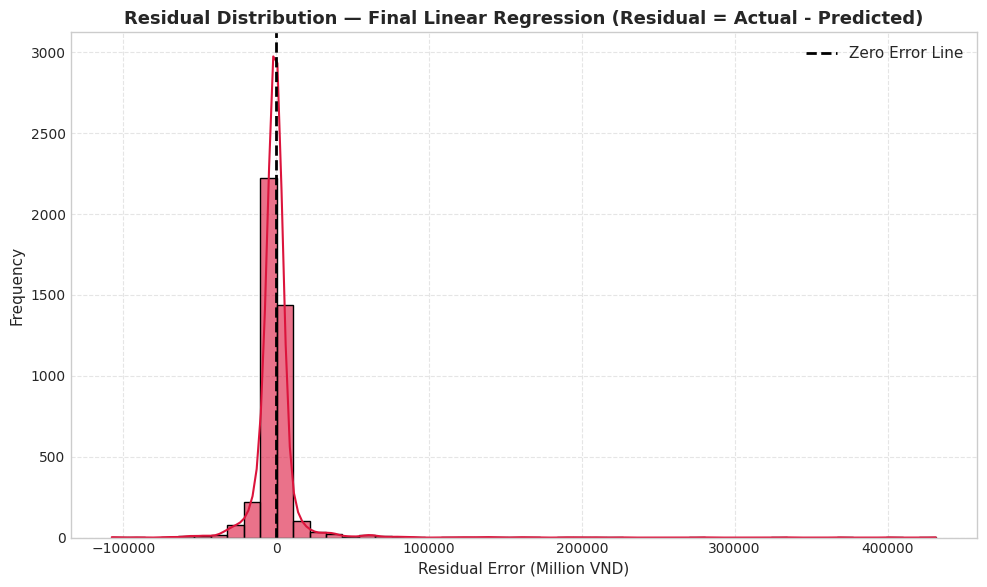

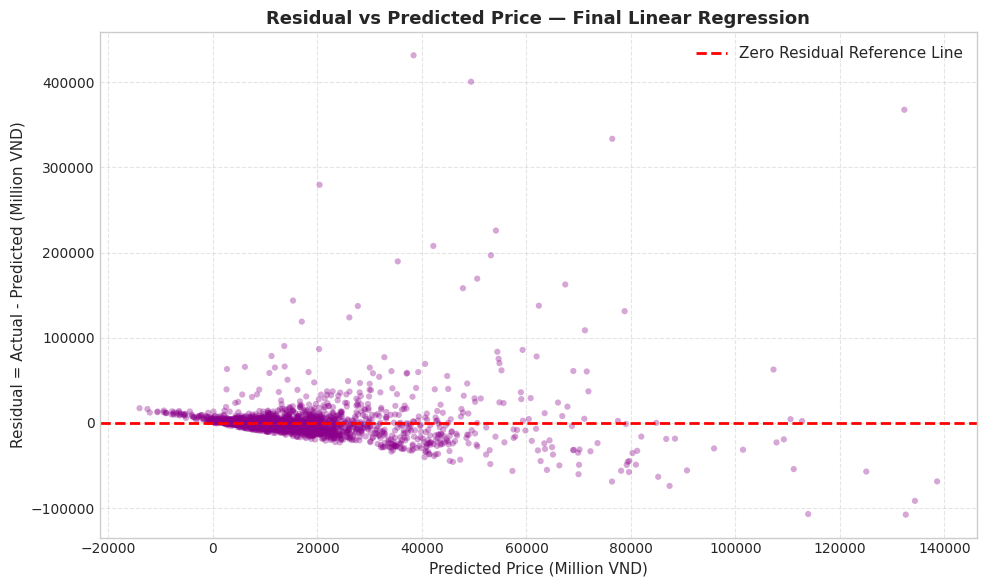

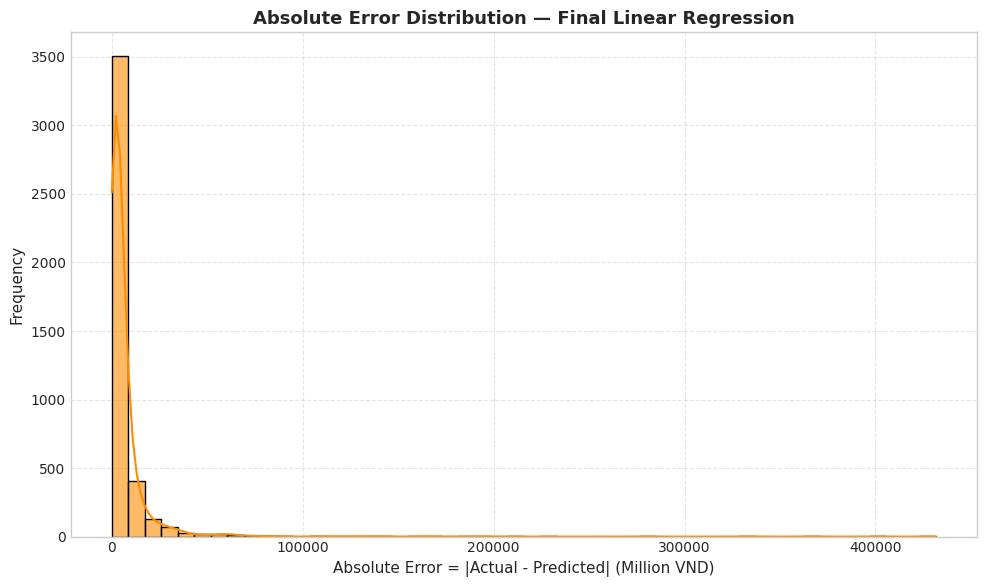

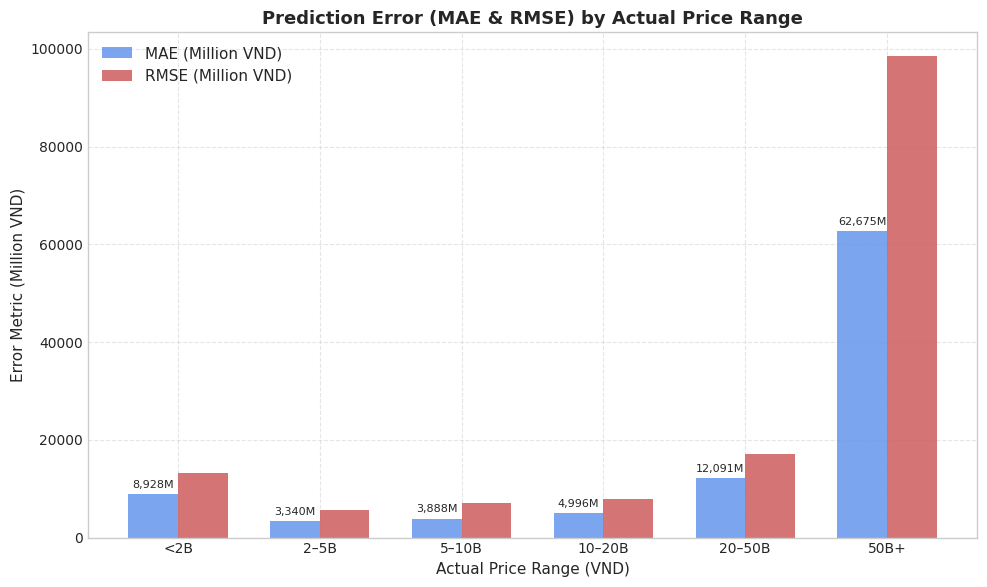

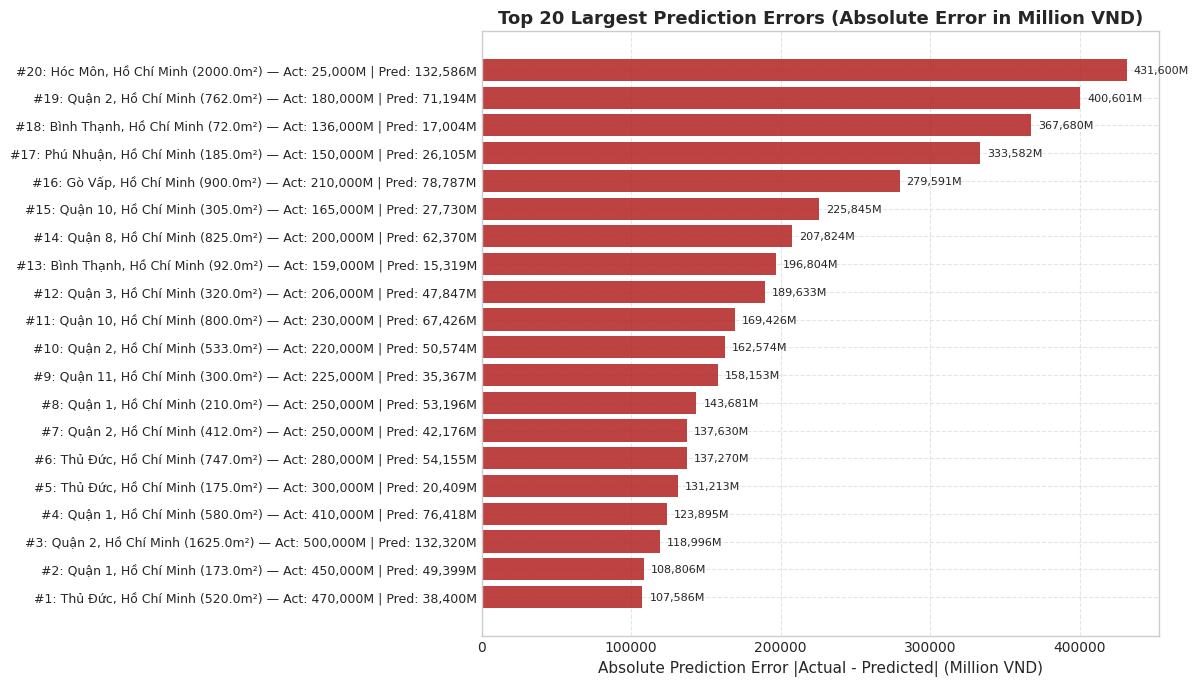

In [3]:
# 1. Performance Visualizations (HCM)
plot_actual_vs_predicted(y_test_hcm, y_pred_hcm, save_path='../reports/figures/10_actual_vs_predicted_hcm.png', show=True)
plot_residual_distribution(y_test_hcm, y_pred_hcm, save_path='../reports/figures/11_residual_distribution_hcm.png', show=True)
plot_residual_vs_predicted(y_test_hcm, y_pred_hcm, save_path='../reports/figures/12_residual_vs_predicted_hcm.png', show=True)

# 2. Error Analysis (HCM)
plot_absolute_error_distribution(y_test_hcm, y_pred_hcm, save_path='../reports/figures/13_absolute_error_distribution_hcm.png', show=True)
plot_error_by_price_range(y_test_hcm, y_pred_hcm, save_path='../reports/figures/14_error_by_price_range_hcm.png', show=True)
plot_top_prediction_errors(X_test_hcm, y_test_hcm, y_pred_hcm, save_path='../reports/figures/15_top_prediction_errors_hcm.png', show=True)


## PHẦN 2: ĐÁNH GIÁ MÔ HÌNH HÀ NỘI

In [4]:
df_hn = df_feat[df_feat['province'] == 'Hà Nội'].copy()
X_hn = df_hn.drop(columns=['price_million_vnd'])
y_hn = df_hn['price_million_vnd']
X_train_hn, X_test_hn, y_train_hn, y_test_hn = train_test_split(X_hn, y_hn, test_size=0.2, random_state=42)

model_hn = joblib.load('../models/linear_regression_hanoi.pkl')
y_pred_hn = model_hn.predict(X_test_hn)

print(f"--- HÀ NỘI METRICS ---")
print(f"Test Set Size: {len(y_test_hn):,} samples")
print(f"R² Score:      {r2_score(y_test_hn, y_pred_hn):.4f}")
print(f"MAE:           {mean_absolute_error(y_test_hn, y_pred_hn):,.2f} million VND")
print(f"RMSE:          {np.sqrt(mean_squared_error(y_test_hn, y_pred_hn)):,.2f} million VND")


--- HÀ NỘI METRICS ---
Test Set Size: 3,976 samples
R² Score:      0.5131
MAE:           8,854.81 million VND
RMSE:          21,407.13 million VND


(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Top 20 Largest Prediction Errors (Absolute Error in Million VND)'}, xlabel='Absolute Prediction Error |Actual - Predicted| (Million VND)'>)

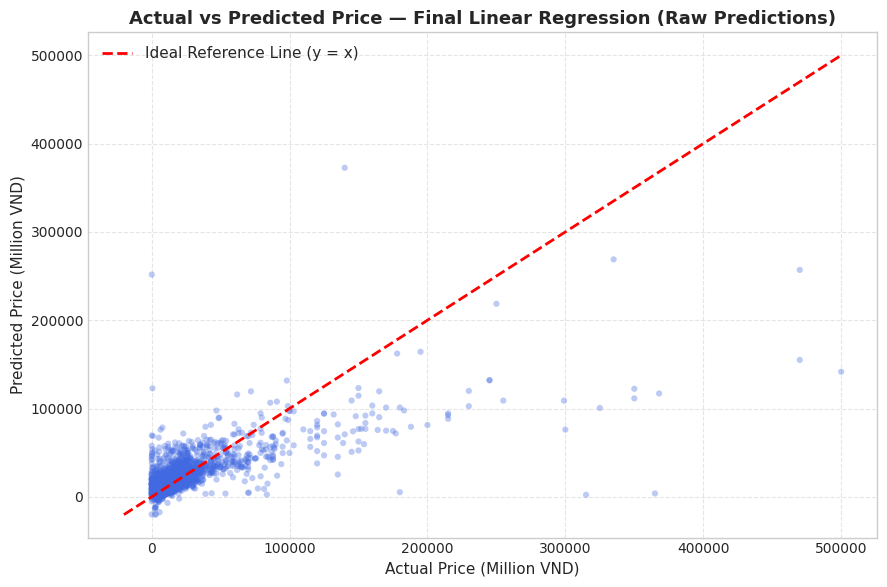

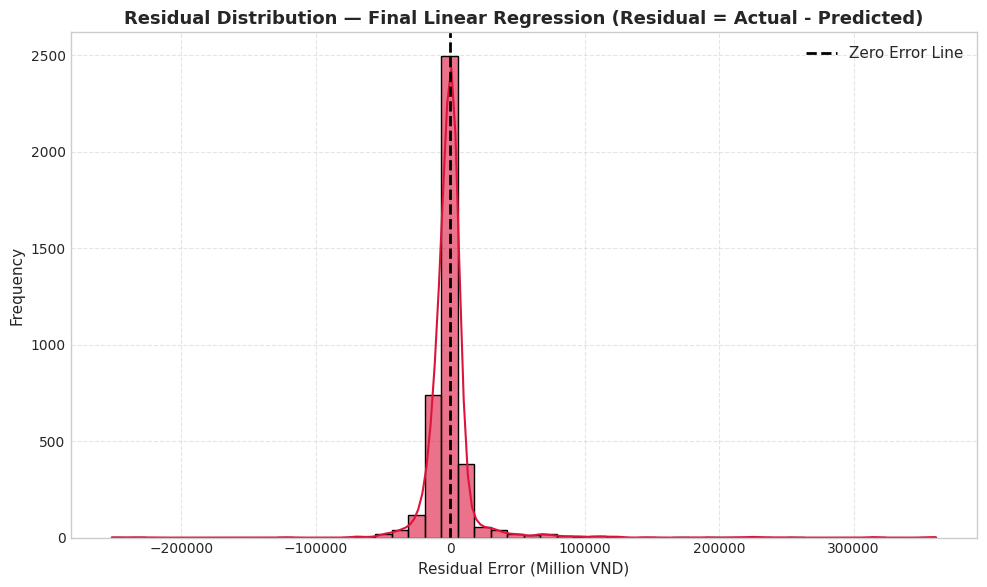

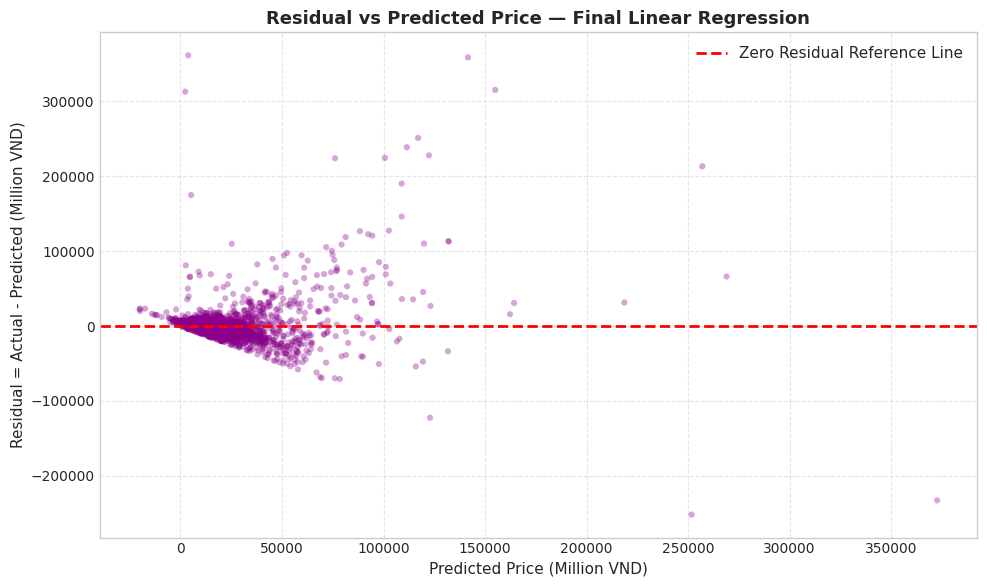

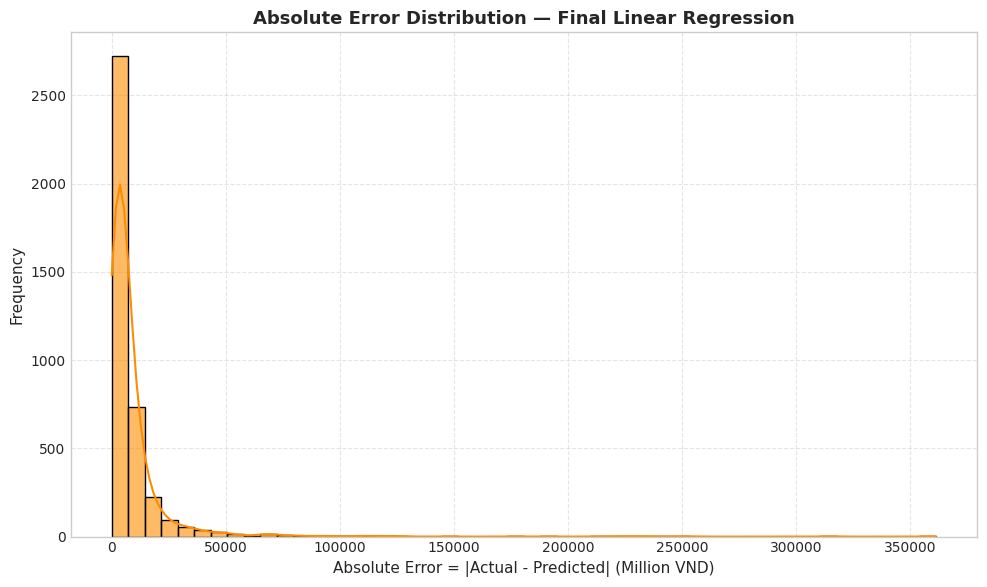

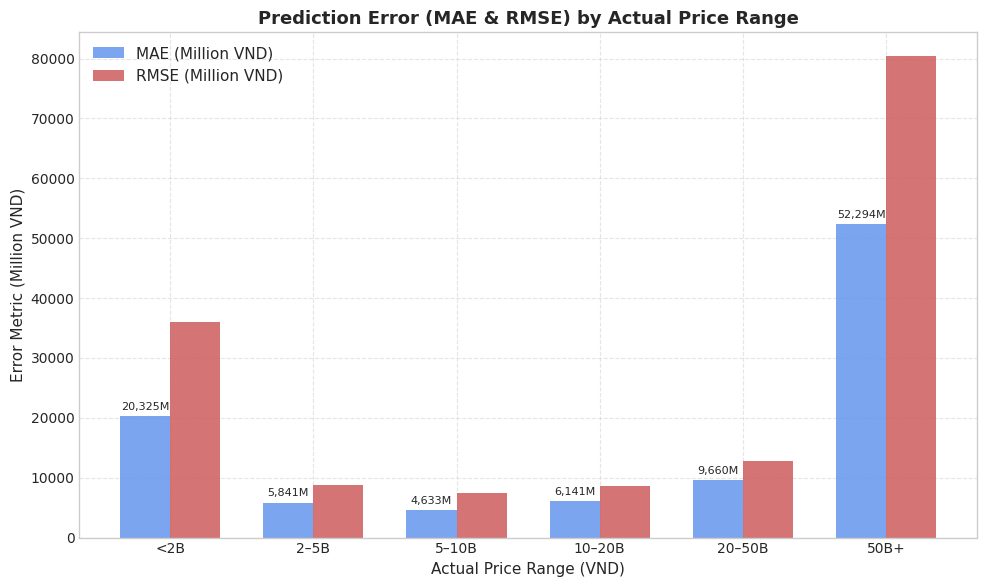

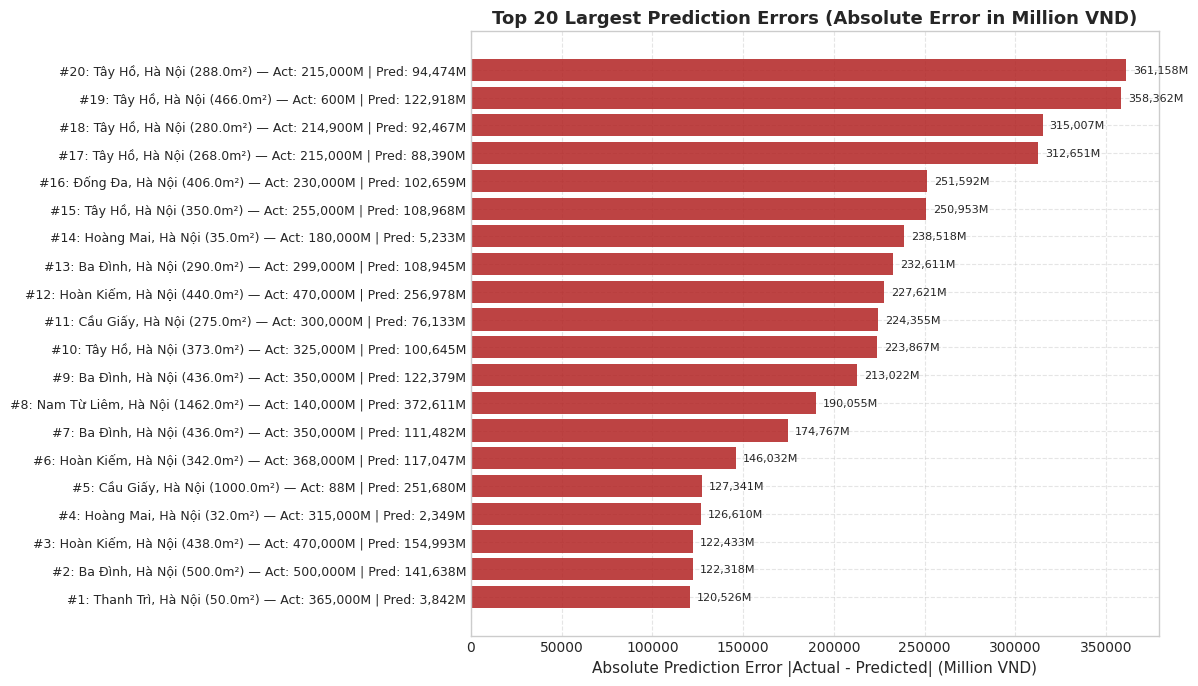

In [5]:
# 1. Performance Visualizations (Hà Nội)
plot_actual_vs_predicted(y_test_hn, y_pred_hn, save_path='../reports/figures/10_actual_vs_predicted_hanoi.png', show=True)
plot_residual_distribution(y_test_hn, y_pred_hn, save_path='../reports/figures/11_residual_distribution_hanoi.png', show=True)
plot_residual_vs_predicted(y_test_hn, y_pred_hn, save_path='../reports/figures/12_residual_vs_predicted_hanoi.png', show=True)

# 2. Error Analysis (Hà Nội)
plot_absolute_error_distribution(y_test_hn, y_pred_hn, save_path='../reports/figures/13_absolute_error_distribution_hanoi.png', show=True)
plot_error_by_price_range(y_test_hn, y_pred_hn, save_path='../reports/figures/14_error_by_price_range_hanoi.png', show=True)
plot_top_prediction_errors(X_test_hn, y_test_hn, y_pred_hn, save_path='../reports/figures/15_top_prediction_errors_hanoi.png', show=True)
